## Creating and running a logistical regression on delphi score - In sample

---

## Installing the packages

In [2]:
import importlib.util
import shutil
import subprocess
import sys
from pathlib import Path

print(f"Notebook Python: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")


def run_command(command):
    completed = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if completed.stdout:
        print(completed.stdout)

    if completed.stderr:
        print(completed.stderr)

    if completed.returncode != 0:
        raise RuntimeError(
            "Package installation failed. "
            "Copy the installation output above so we can identify the cause."
        )


required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",
    "IPython": "ipython",
}

missing = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print(f"Installing: {', '.join(missing)}")

    uv_executable = shutil.which("uv")

    if uv_executable:
        # Install into the exact environment used by this notebook.
        run_command([
            uv_executable,
            "pip",
            "install",
            "--python",
            sys.executable,
            *missing,
        ])
    else:
        # Some uv-created environments do not include pip.
        if importlib.util.find_spec("pip") is None:
            run_command([
                sys.executable,
                "-m",
                "ensurepip",
                "--upgrade",
            ])

        run_command([
            sys.executable,
            "-m",
            "pip",
            "install",
            *missing,
        ])

    importlib.invalidate_caches()

import numpy as np
import pandas as pd
import statsmodels.api as sm

from IPython.display import display
from sklearn.metrics import roc_auc_score, brier_score_loss

print("Required packages are installed and imported successfully.")

Notebook Python: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\.venv\Scripts\python.exe
Python version: 3.14.7
Required packages are installed and imported successfully.


### Pulling the KGB datasets

In [3]:
DATA_PATH = Path(
    r"C:\Users\georg\OneDrive\Coding\Origination-Scorecard"
    r"\data\KGB Modelling\KGB in sample.csv"
)

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

kgb = pd.read_csv(
    DATA_PATH,
    usecols=["account_id", "DelphiScore", "target_bad"],
    dtype={"account_id": "string"},
)

print(f"Loaded {len(kgb):,} accounts from:\n{DATA_PATH}")

Loaded 7,258 accounts from:
C:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB in sample.csv


## Validate and fit the regression - calculate residual

In [4]:
# Validate the existing data; do not redefine the target or sample.
if kgb["account_id"].isna().any() or kgb["account_id"].duplicated().any():
    raise ValueError("Missing or duplicate account IDs must be resolved.")

for column in ["DelphiScore", "target_bad"]:
    kgb[column] = pd.to_numeric(kgb[column], errors="coerce")

if not np.isfinite(kgb[["DelphiScore", "target_bad"]].to_numpy()).all():
    raise ValueError("DelphiScore or target_bad contains missing/invalid values.")

if not kgb["target_bad"].isin([0, 1]).all():
    raise ValueError("target_bad must contain only 0 and 1.")

if kgb["target_bad"].nunique() != 2:
    raise ValueError("Both good and bad accounts are required.")

if kgb["DelphiScore"].nunique() < 2:
    raise ValueError("DelphiScore must vary across accounts.")

y = kgb["target_bad"].astype(int)
X = sm.add_constant(
    kgb[["DelphiScore"]].astype(float),
    has_constant="add",
)

# Fit using Delphi score only, plus an intercept.
result = sm.Logit(y, X).fit(disp=False, maxiter=200)

if not result.mle_retvals["converged"]:
    raise RuntimeError("Logistic regression did not converge.")

# Keep predictions and residuals separate from the loaded dataset.
diagnostics = kgb.copy()
diagnostics["predicted_pd"] = result.predict(X)
diagnostics["response_residual"] = y - diagnostics["predicted_pd"]

# Clip probabilities only for numerical safety in residual calculations.
p = np.clip(diagnostics["predicted_pd"].to_numpy(), 1e-12, 1 - 1e-12)
observed = y.to_numpy()

diagnostics["pearson_residual"] = (
    (observed - p) / np.sqrt(p * (1 - p))
)

deviance_contribution = -2 * (
    observed * np.log(p)
    + (1 - observed) * np.log1p(-p)
)

diagnostics["deviance_residual"] = (
    np.sign(observed - p) * np.sqrt(deviance_contribution)
)

ssr = float(np.square(diagnostics["response_residual"]).sum())

print("Regression fitted successfully.")

Regression fitted successfully.


## Display the results

In [5]:
def gini_coefficient(y_true, y_score):
    """Normalized Gini coefficient for binary classification."""
    auc = roc_auc_score(y_true, y_score)
    return 2 * auc - 1


ci = result.conf_int(alpha=0.05)

coefficient_table = pd.DataFrame({
    "Coefficient": result.params,
    "Standard error": result.bse,
    "Z-statistic": result.tvalues,
    "P-value": result.pvalues,
    "95% CI lower": ci[0],
    "95% CI upper": ci[1],
    "Odds ratio": np.exp(result.params),
}).loc[["const", "DelphiScore"]].rename(
    index={"const": "Intercept"}
)

# Calculate directly from the fitted model.
predicted_pd = result.predict()

residual_sum_of_squares = float(
    np.square(y.to_numpy() - predicted_pd).sum()
)

in_sample_auc = roc_auc_score(y, predicted_pd)
in_sample_gini = gini_coefficient(y, predicted_pd)

fit_statistics = pd.Series({
    "McFadden pseudo-R²": result.prsquared,
    "Log-likelihood": result.llf,
    "AIC": result.aic,
    "Residual sum of squares": residual_sum_of_squares,
    "ROC AUC (in-sample)": in_sample_auc,
    "Gini coefficient (in-sample)": in_sample_gini,
}, name="Value")

print("COEFFICIENTS — 95% Wald confidence intervals")
display(coefficient_table)

print("\nMODEL FIT — in-sample")
display(fit_statistics.to_frame())

COEFFICIENTS — 95% Wald confidence intervals


,Coefficient,Standard error,Z-statistic,P-value,95% CI lower,95% CI upper,Odds ratio
Intercept,-0.466869,0.739282,-0.631517,0.527703,-1.915835,0.982097,0.626962
DelphiScore,-0.003302,0.000909,-3.632860,0.000280,-0.005083,-0.001520,0.996704



MODEL FIT — in-sample


,Value
McFadden pseudo-R²,0.005294
Log-likelihood,-1224.095366
AIC,2452.190731
Residual sum of squares,281.499842
ROC AUC (in-sample),0.553327
Gini coefficient (in-sample),0.106654


---

# Out-sample

## Opening the out-sample

In [6]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(
    r"C:\Users\georg\OneDrive\Coding\Origination-Scorecard"
)

candidate_paths = [
    PROJECT_DIR / "data" / "KGB Modelling" / "KGB out sample.csv",
    PROJECT_DIR / "data" / "KGB out sample.csv",
]

OUT_SAMPLE_PATH = next(
    (path for path in candidate_paths if path.is_file()),
    None,
)

if OUT_SAMPLE_PATH is None:
    raise FileNotFoundError(
        "Could not find KGB out sample.csv. Checked:\n"
        + "\n".join(str(path) for path in candidate_paths)
    )

out_sample = pd.read_csv(
    OUT_SAMPLE_PATH,
    dtype={"account_id": "string"},
)

In [7]:
# Point estimates on the out-sample
X_out = sm.add_constant(
    out_sample[["DelphiScore"]].astype(float),
    has_constant="add",
)

out_sample["predicted_pd"] = result.predict(X_out)

In [8]:
from sklearn.metrics import roc_auc_score

# Compare actual outcomes with the predicted probability of being bad.
auc_out = roc_auc_score(
    out_sample["target_bad"],
    out_sample["predicted_pd"],
)

gini_out = 2 * auc_out - 1

print(f"Out-of-sample ROC AUC: {auc_out:.4f}")
print(f"Out-of-sample Gini / Accuracy Ratio: {gini_out:.4f} ({gini_out:.2%})")

Out-of-sample ROC AUC: 0.5702
Out-of-sample Gini / Accuracy Ratio: 0.1405 (14.05%)


Discriminatory power of the model has improved into the out sample - no model drift, low discrinatory power

---

# Calibration

DELPHI-ONLY OUT-OF-SAMPLE CALIBRATION BY RISK BAND


,risk_band,accounts,actual_bads,average_predicted_pd,actual_bad_rate,lowest_predicted_pd,highest_predicted_pd,difference
0,1,250,3,2.85%,1.20%,2.26%,3.09%,-1.65%
1,2,250,13,3.23%,5.20%,3.10%,3.35%,+1.97%
2,3,243,8,3.46%,3.29%,3.36%,3.54%,-0.16%
3,4,246,7,3.64%,2.85%,3.55%,3.73%,-0.79%
4,5,250,10,3.83%,4.00%,3.74%,3.91%,+0.17%
5,6,251,12,4.03%,4.78%,3.93%,4.13%,+0.76%
6,7,231,9,4.25%,3.90%,4.14%,4.36%,-0.35%
7,8,245,13,4.50%,5.31%,4.37%,4.64%,+0.81%
8,9,247,12,4.88%,4.86%,4.66%,5.12%,-0.02%
9,10,245,15,5.72%,6.12%,5.13%,8.38%,+0.40%


Overall average predicted PD: 4.03%
Overall actual bad rate: 4.15%


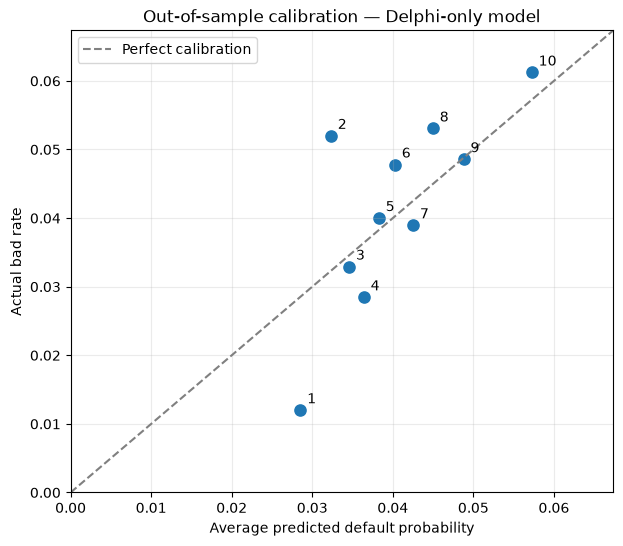

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

delphi_calibration_data = pd.DataFrame({
    "predicted_pd": np.asarray(
        out_sample["predicted_pd"], dtype=float
    ),
    "actual_bad": np.asarray(
        out_sample["target_bad"], dtype=int
    ),
})

if not np.isfinite(
    delphi_calibration_data["predicted_pd"]
).all():
    raise ValueError("Predicted probabilities contain invalid values.")

# Divide accounts into ten groups by predicted default probability.
delphi_calibration_data["band"] = pd.qcut(
    delphi_calibration_data["predicted_pd"],
    q=10,
    duplicates="drop",
)

delphi_calibration_table = (
    delphi_calibration_data
    .groupby("band", observed=True)
    .agg(
        accounts=("actual_bad", "size"),
        actual_bads=("actual_bad", "sum"),
        average_predicted_pd=("predicted_pd", "mean"),
        actual_bad_rate=("actual_bad", "mean"),
        lowest_predicted_pd=("predicted_pd", "min"),
        highest_predicted_pd=("predicted_pd", "max"),
    )
    .reset_index(drop=True)
)

delphi_calibration_table.insert(
    0,
    "risk_band",
    range(1, len(delphi_calibration_table) + 1),
)

delphi_calibration_table["difference"] = (
    delphi_calibration_table["actual_bad_rate"]
    - delphi_calibration_table["average_predicted_pd"]
)

print("DELPHI-ONLY OUT-OF-SAMPLE CALIBRATION BY RISK BAND")
display(
    delphi_calibration_table.style.format({
        "average_predicted_pd": "{:.2%}",
        "actual_bad_rate": "{:.2%}",
        "lowest_predicted_pd": "{:.2%}",
        "highest_predicted_pd": "{:.2%}",
        "difference": "{:+.2%}",
    })
)

print(
    f"Overall average predicted PD: "
    f"{delphi_calibration_data['predicted_pd'].mean():.2%}"
)
print(
    f"Overall actual bad rate: "
    f"{delphi_calibration_data['actual_bad'].mean():.2%}"
)

# Plot observed versus predicted bad rates.
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    delphi_calibration_table["average_predicted_pd"],
    delphi_calibration_table["actual_bad_rate"],
    s=65,
)

for row in delphi_calibration_table.itertuples():
    ax.annotate(
        str(row.risk_band),
        (row.average_predicted_pd, row.actual_bad_rate),
        xytext=(5, 5),
        textcoords="offset points",
    )

upper_limit = max(
    delphi_calibration_table["average_predicted_pd"].max(),
    delphi_calibration_table["actual_bad_rate"].max(),
    0.01,
) * 1.1

ax.plot(
    [0, upper_limit],
    [0, upper_limit],
    linestyle="--",
    color="grey",
    label="Perfect calibration",
)

ax.set_xlim(0, upper_limit)
ax.set_ylim(0, upper_limit)
ax.set_xlabel("Average predicted default probability")
ax.set_ylabel("Actual bad rate")
ax.set_title("Out-of-sample calibration — Delphi-only model")
ax.legend()
ax.grid(alpha=0.25)

plt.show()